<a href="https://colab.research.google.com/github/Tantoluwa/2018-02-23-MetaDC/blob/gh-pages/16S_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os
os.makedirs("/content/drive/MyDrive/databases", exist_ok=True)

In [ ]:
!wget -O /content/drive/MyDrive/databases/silva_nr99_v138.1_train_set.fa.gz https://zenodo.org/record/4587955/files/silva_nr99_v138.1_train_set.fa.gz?download=1

--2025-04-01 17:19:11--  https://zenodo.org/record/4587955/files/silva_nr99_v138.1_train_set.fa.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.45.92, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4587955/files/silva_nr99_v138.1_train_set.fa.gz [following]
--2025-04-01 17:19:11--  https://zenodo.org/records/4587955/files/silva_nr99_v138.1_train_set.fa.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 137283333 (131M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/databases/silva_nr99_v138.1_train_set.fa.gz’

/content/drive/MyDr 100%[===================>] 130.92M  28.3MB/s    in 5.8s    

2025-04-01 17:19:17 (22.5 MB/s) - ‘/content/drive/MyDrive/databases/silva_nr99_v138.1_train_set.fa.gz’ saved [137283333/137283333]



In [14]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [15]:
%%R
install.packages("BiocManager", repos='http://cran.us.r-project.org')
BiocManager::install("dada2")
install.packages("ggplot2", repos='http://cran.us.r-project.org')

Update all/some/none? [a/s/n]: a


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/src/contrib/BiocManager_1.30.25.tar.gz'
Content type 'application/x-gzip' length 593414 bytes (579 KB)
downloaded 579 KB


The downloaded source packages are in
	‘/tmp/Rtmpg86Zg1/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.3 (2025-02-28)
Installing package(s) 'BiocVersion', 'dada2'
also installing the dependencies ‘formatR’, ‘matrixStats’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘MatrixGenerics’, ‘S4Arrays’, ‘DelayedArray’, ‘deldir’, ‘RcppEigen’, ‘UCSC.utils’, ‘GenomeInfoDbData’, ‘futile.logger’, ‘snow’, ‘BH’, ‘bitops’, ‘SummarizedExperiment’, ‘png’, ‘jpeg’, ‘interp’, ‘S4Vectors’, ‘GenomeInfoDb’, ‘plyr’, ‘BiocParallel’, ‘Rsamtools’

In [ ]:
%%R
library(dada2)
path <- "/content/drive/MyDrive/amplicon_data 16S"

# Rerun these if needed
fnFs <- sort(list.files(path, pattern="_R1.fastq.gz", full.names=TRUE))
fnRs <- sort(list.files(path, pattern="_R2.fastq.gz", full.names=TRUE))

Loading required package: Rcpp


In [ ]:
%%R
filtFs <- file.path(path, "filtered", basename(fnFs))
filtRs <- file.path(path, "filtered", basename(fnRs))


In [ ]:
%%R
errF <- learnErrors(filtFs, nbases=1e6, multithread=FALSE)
errR <- learnErrors(filtRs, nbases=1e6, multithread=FALSE)

47847360 total bases in 199364 reads from 1 samples will be used for learning the error rates.
31898240 total bases in 199364 reads from 1 samples will be used for learning the error rates.


In [ ]:
%%R
# Dereplication
derepFs <- derepFastq(filtFs)
derepRs <- derepFastq(filtRs)

# Assign sample names
names(derepFs) <- sapply(strsplit(basename(filtFs), "_"), `[`, 1)
names(derepRs) <- sapply(strsplit(basename(filtRs), "_"), `[`, 1)

# Denoise (ASV inference)
dadaFs <- dada(derepFs, err=errF, multithread=FALSE)
dadaRs <- dada(derepRs, err=errR, multithread=FALSE)

Sample 1 - 199364 reads in 50025 unique sequences.
Sample 2 - 158798 reads in 43413 unique sequences.
Sample 3 - 219731 reads in 61225 unique sequences.
Sample 4 - 205962 reads in 60843 unique sequences.
Sample 5 - 207573 reads in 60306 unique sequences.
Sample 6 - 190466 reads in 54183 unique sequences.
Sample 7 - 87 reads in 52 unique sequences.
Sample 1 - 199364 reads in 44905 unique sequences.
Sample 2 - 158798 reads in 37524 unique sequences.
Sample 3 - 219731 reads in 53565 unique sequences.
Sample 4 - 205962 reads in 52511 unique sequences.
Sample 5 - 207573 reads in 52014 unique sequences.
Sample 6 - 190466 reads in 47691 unique sequences.
Sample 7 - 87 reads in 75 unique sequences.


In [ ]:
%%R
# Merge paired reads
mergers <- mergePairs(dadaFs, derepFs, dadaRs, derepRs)

In [ ]:
%%R
# Make ASV table
seqtab <- makeSequenceTable(mergers)

# Remove chimeras
seqtab.nochim <- removeBimeraDenovo(seqtab, method="consensus", multithread=FALSE)

# Print basic stats
dim(seqtab)
dim(seqtab.nochim)

[1]    7 1464


In [16]:
%%R
library(dada2)


Loading required package: Rcpp


In [20]:
%%R
# Set your 16S filtered path
path <- "/content/drive/MyDrive/amplicon_data 16S"

# Reload your filtered FASTQ files
filtFs <- sort(list.files(file.path(path, "filtered"), pattern="_R1.fastq.gz", full.names = TRUE))
filtRs <- sort(list.files(file.path(path, "filtered"), pattern="_R2.fastq.gz", full.names = TRUE))


In [21]:
%%R
errF <- learnErrors(filtFs, nbases=1e6, multithread=FALSE)
errR <- learnErrors(filtRs, nbases=1e6, multithread=FALSE)

47847360 total bases in 199364 reads from 1 samples will be used for learning the error rates.
31898240 total bases in 199364 reads from 1 samples will be used for learning the error rates.


In [22]:
%%R
derepFs <- derepFastq(filtFs)
derepRs <- derepFastq(filtRs)

names(derepFs) <- sapply(strsplit(basename(filtFs), "_"), `[`, 1)
names(derepRs) <- sapply(strsplit(basename(filtRs), "_"), `[`, 1)

dadaFs <- dada(derepFs, err=errF)
dadaRs <- dada(derepRs, err=errR)

mergers <- mergePairs(dadaFs, derepFs, dadaRs, derepRs)

seqtab <- makeSequenceTable(mergers)
seqtab.nochim <- removeBimeraDenovo(seqtab, method="consensus", multithread=FALSE)


Sample 1 - 199364 reads in 50025 unique sequences.
Sample 2 - 158798 reads in 43413 unique sequences.
Sample 3 - 219731 reads in 61225 unique sequences.
Sample 4 - 205962 reads in 60843 unique sequences.
Sample 5 - 207573 reads in 60306 unique sequences.
Sample 6 - 190466 reads in 54183 unique sequences.
Sample 7 - 87 reads in 52 unique sequences.
Sample 1 - 199364 reads in 44905 unique sequences.
Sample 2 - 158798 reads in 37524 unique sequences.
Sample 3 - 219731 reads in 53565 unique sequences.
Sample 4 - 205962 reads in 52511 unique sequences.
Sample 5 - 207573 reads in 52014 unique sequences.
Sample 6 - 190466 reads in 47691 unique sequences.
Sample 7 - 87 reads in 75 unique sequences.


In [23]:
%%R
taxa <- assignTaxonomy(seqtab.nochim, "/content/drive/MyDrive/databases/silva_nr99_v138.1_train_set.fa.gz", multithread=FALSE)

In [26]:
%%R
dir.create("/content/drive/MyDrive/output", showWarnings = FALSE)

In [27]:
%%R
write.csv(seqtab.nochim, "/content/drive/MyDrive/output/16S_ASV_table.csv")

In [28]:
%%R
head(seqtab.nochim)
head(taxa)

                                                                                                                                                                                                                                                                                                         Kingdom   
TGTGCCAGCCGCCGCGGTAATACGTAGGTGGCAAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGTTTCTTAAGTCTGATGTGAAAGCCTTCGGCTTAACCGGAGAAGTGCATCGGAAACTGGGAGACTTGAGTGCAGAAGAGGACAGTGGAACTCCATGTGTAGCGGTGGAATGCGTAGATATATGGAAGAACACCAGTGGCGAAGGCGGCTGTCTAGTCTGTAACTGACGCTGAGGCTCGAAAGCATGGGTAGCAAACAGGATTAGAAACCCCAGTAGTCCA   "Bacteria"
TGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGTTTCTTAAGTCTGATGTGAAAGCCTTCGGCTTAACCGGAGAAGTGCATCGGAAACTGGGAGACTTGAGTGCAGAAGAGGACAGTGGAACTCCATGTGTAGCGGTGGAATGCGTAGATATATGGAAGAACACCAGTGGCGAAGGCGGCTGTCTAGTCTGTAACTGACGCTGAGGCTCGAAAGCATGGGTAGCAAACAGGATTAGAAACCCCAGTAGTCCA   "Bacteria"
TGTGCCAGCCGCCGCGGTAATACGTAGGTGGCAAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGT

In [29]:
%%R
install.packages("tidyverse", repos = "http://cran.us.r-project.org")
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/src/contrib/tidyverse_2.0.0.tar.gz'
Content type 'application/x-gzip' length 704618 bytes (688 KB)
downloaded 688 KB


The downloaded source packages are in
	‘/tmp/Rtmpg86Zg1/downloaded_packages’


In [33]:
%%R
# Convert ASV counts to relative abundance
rel_abund <- sweep(seqtab.nochim, 1, rowSums(seqtab.nochim), FUN="/")

# Combine with taxonomy
taxa_df <- as.data.frame(taxa)
rel_abund_df <- as.data.frame(rel_abund)
rel_abund_df$Sample <- rownames(rel_abund_df)

# Reshape to long format
library(tidyr)
rel_abund_long <- pivot_longer(rel_abund_df, cols = -Sample, names_to = "ASV", values_to = "Abundance")

# Add phylum
rel_abund_long$Phylum <- taxa_df[rel_abund_long$ASV, "Phylum"]
rel_abund_long <- na.omit(rel_abund_long)

# Group by phylum and sample, sum abundances
library(dplyr)
plot_df <- rel_abund_long %>%
  group_by(Sample, Phylum) %>%
  summarise(TotalAbundance = sum(Abundance), .groups = "drop")

# Identify top 10 most abundant phyla
top_phyla <- plot_df %>%
  group_by(Phylum) %>%
  summarise(SumAbund = sum(TotalAbundance), .groups = "drop") %>%
  top_n(10, SumAbund) %>%
  pull(Phylum)

# Collapse rare phyla into "Other"
plot_df <- plot_df %>%
  mutate(Phylum = ifelse(Phylum %in% top_phyla, Phylum, "Other"))

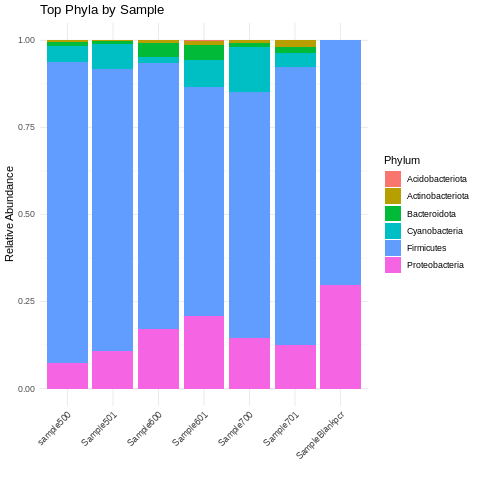

In [34]:
%%R
library(ggplot2)

ggplot(plot_df, aes(x = Sample, y = TotalAbundance, fill = Phylum)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Top Phyla by Sample", y = "Relative Abundance", x = "") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [36]:
%%R
install.packages("vegan", repos = "http://cran.us.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘permute’

trying URL 'http://cran.us.r-project.org/src/contrib/permute_0.9-7.tar.gz'
Content type 'application/x-gzip' length 114805 bytes (112 KB)
downloaded 112 KB

trying URL 'http://cran.us.r-project.org/src/contrib/vegan_2.6-10.tar.gz'
Content type 'application/x-gzip' length 1502105 bytes (1.4 MB)
downloaded 1.4 MB


The downloaded source packages are in
	‘/tmp/Rtmpg86Zg1/downloaded_packages’


In [37]:
%%R
library(vegan)

# Observed richness
observed_richness <- rowSums(seqtab.nochim > 0)

# Shannon index
shannon <- diversity(seqtab.nochim, index = "shannon")

# Save to data frame
alpha_df <- data.frame(Sample = names(shannon),
                       Observed_ASVs = observed_richness,
                       Shannon = shannon)

# View
alpha_df

                       Sample Observed_ASVs  Shannon
sample500           sample500           471 5.340139
Sample501           Sample501           438 5.372775
Sample600           Sample600           526 5.473720
Sample601           Sample601           515 5.665301
Sample700           Sample700           442 5.484983
Sample701           Sample701           470 5.466092
SampleBlankpcr SampleBlankpcr             3 0.802748


Loading required package: permute
Loading required package: lattice
This is vegan 2.6-10


In [38]:
%%R
write.csv(alpha_df, "/content/drive/MyDrive/output/16S_alpha_diversity.csv", row.names = FALSE)

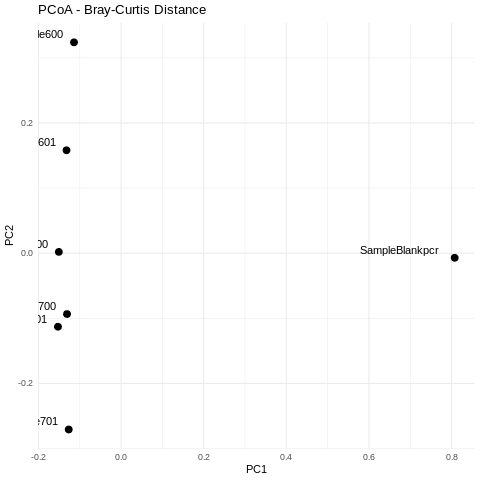

In [39]:
%%R
# Bray-Curtis distance
dist_bc <- vegdist(seqtab.nochim, method = "bray")

# PCoA
pcoa <- cmdscale(dist_bc, eig = TRUE, k = 2)

# Create plot df
pcoa_df <- data.frame(Sample = rownames(seqtab.nochim),
                      PC1 = pcoa$points[,1],
                      PC2 = pcoa$points[,2])

# Plot
ggplot(pcoa_df, aes(x = PC1, y = PC2, label = Sample)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.5, hjust = 1.2) +
  theme_minimal() +
  labs(title = "PCoA - Bray-Curtis Distance",
       x = "PC1", y = "PC2")

In [40]:
%%R
library(ggplot2)

# Create plot object
p <- ggplot(pcoa_df, aes(x = PC1, y = PC2, label = Sample)) +
  geom_point(size = 3, color = "steelblue") +
  geom_text(vjust = -0.5, hjust = 1.2) +
  theme_minimal() +
  labs(title = "PCoA - Bray-Curtis Distance",
       x = "PC1", y = "PC2")

# Save plot to Google Drive
ggsave("/content/drive/MyDrive/output/16S_pcoa_plot.png", plot = p, width = 8, height = 6, dpi = 300)


In [41]:
%%R
# Load vegan if not already
library(vegan)

# Open graphics device
png("/content/drive/MyDrive/output/16S_rarefaction_curves.png", width = 1000, height = 800)

# Plot rarefaction
rarecurve(seqtab.nochim,
          step = 1000,
          sample = min(rowSums(seqtab.nochim)),
          col = rainbow(nrow(seqtab.nochim)),
          label = TRUE,
          main = "Rarefaction Curves")

# Close graphics device
dev.off()

png 
  2 


In [ ]:
%%R
# Load pheatmap
install.packages("pheatmap", repos = "http://cran.us.r-project.org")
library(pheatmap)

# Select top 20 most abundant ASVs
top_asvs <- names(sort(colSums(seqtab.nochim), decreasing=TRUE)[1:20])
heat_data <- seqtab.nochim[, top_asvs]

# Save heatmap as PNG
png("/content/drive/MyDrive/output/16S_top20_ASVs_heatmap.png", width = 1000, height = 800)
pheatmap(log1p(heat_data), fontsize_row = 8, main = "Top 20 ASVs Heatmap")
dev.off()


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
!wget -O "/content/drive/MyDrive/databases/silva_species_assignment_v138.1.fa.gz" \
https://zenodo.org/record/4587955/files/silva_species_assignment_v138.1.fa.gz?download=1

--2025-04-02 15:30:16--  https://zenodo.org/record/4587955/files/silva_species_assignment_v138.1.fa.gz?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.45.92, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4587955/files/silva_species_assignment_v138.1.fa.gz [following]
--2025-04-02 15:30:17--  https://zenodo.org/records/4587955/files/silva_species_assignment_v138.1.fa.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 78672696 (75M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/databases/silva_species_assignment_v138.1.fa.gz’

/content/drive/MyDr 100%[===================>]  75.03M   901KB/s    in 90s     

2025-04-02 15:31:47 (851 KB/s) - ‘/content/drive/MyDrive/databases/silva_species_assignment_v138.1.fa.gz’ saved [78672696/78672696]



In [46]:
os.listdir("/content/drive/MyDrive/databases")

['silva_nr99_v138.1_train_set.fa.gz', 'silva_species_assignment_v138.1.fa.gz']

In [47]:
%%R
taxa <- addSpecies(taxa, "/content/drive/MyDrive/databases/silva_species_assignment_v138.1.fa.gz")

In [48]:
%%R
# Preview some species-level assignments
head(taxa[, c("Genus", "Species")], 10)

# Count how many ASVs got species-level assignments
table(!is.na(taxa[, "Species"]))


FALSE 
 1464 


In [49]:
%%R
# Number of ASVs with non-missing data at each level
colSums(!is.na(taxa))


Kingdom  Phylum   Class   Order  Family   Genus Species 
   1464    1464    1464    1464    1314     966       0 


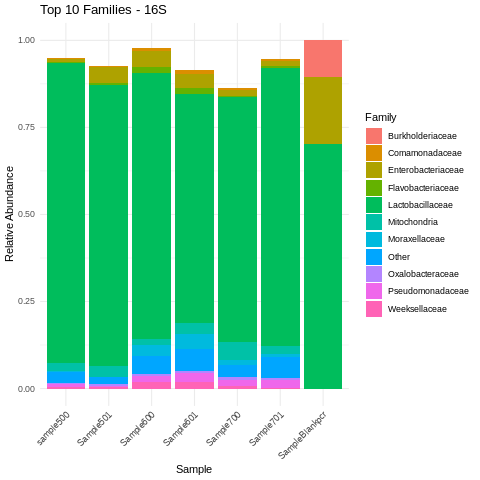

In [50]:
%%R
# Prepare abundance + taxonomy
library(dplyr)
library(tidyr)

asv_rel_abund <- sweep(seqtab.nochim, 1, rowSums(seqtab.nochim), "/")
rel_df <- as.data.frame(asv_rel_abund)
rel_df$Sample <- rownames(rel_df)

# Pivot longer
long_df <- pivot_longer(rel_df, cols = -Sample, names_to = "ASV", values_to = "Abundance")
long_df$Family <- taxa[long_df$ASV, "Family"]
long_df <- na.omit(long_df)

# Summarize by Family
plot_family <- long_df %>%
  group_by(Sample, Family) %>%
  summarise(TotalAbundance = sum(Abundance), .groups = "drop")

# Top 10 Families
top_fam <- plot_family %>%
  group_by(Family) %>%
  summarise(SumAbund = sum(TotalAbundance)) %>%
  top_n(10, SumAbund) %>%
  pull(Family)

# Replace others with "Other"
plot_family <- plot_family %>%
  mutate(Family = ifelse(Family %in% top_fam, Family, "Other"))

# Plot
library(ggplot2)
ggplot(plot_family, aes(x = Sample, y = TotalAbundance, fill = Family)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Top 10 Families - 16S", y = "Relative Abundance") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


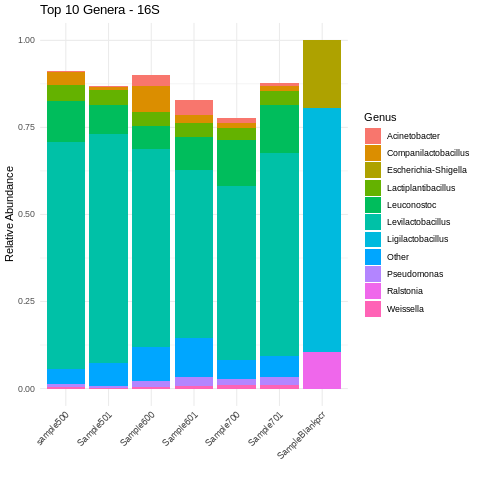

In [52]:
%%R
library(dplyr)
library(tidyr)
library(ggplot2)

# Normalize counts to relative abundance
asv_rel_abund <- sweep(seqtab.nochim, 1, rowSums(seqtab.nochim), "/")
rel_df <- as.data.frame(asv_rel_abund)
rel_df$Sample <- rownames(rel_df)

# Pivot to long format
long_df <- pivot_longer(rel_df, cols = -Sample, names_to = "ASV", values_to = "Abundance")

# Add Genus information from taxonomy
long_df$Genus <- taxa[long_df$ASV, "Genus"]
long_df <- na.omit(long_df)

# Summarize abundance by Genus per Sample
plot_genus <- long_df %>%
  group_by(Sample, Genus) %>%
  summarise(TotalAbundance = sum(Abundance), .groups = "drop")

# Find top 10 most abundant genera across all samples
top_gen <- plot_genus %>%
  group_by(Genus) %>%
  summarise(SumAbund = sum(TotalAbundance), .groups = "drop") %>%
  top_n(10, SumAbund) %>%
  pull(Genus)

# Group less abundant genera under "Other"
plot_genus <- plot_genus %>%
  mutate(Genus = ifelse(Genus %in% top_gen, Genus, "Other"))

# Plot it
ggplot(plot_genus, aes(x = Sample, y = TotalAbundance, fill = Genus)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Top 10 Genera - 16S", y = "Relative Abundance", x = "") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [53]:
%%R
write.csv(taxa, "/content/drive/MyDrive/output/16S_taxonomy_all_levels.csv")

In [54]:
%%R
ggsave("/content/drive/MyDrive/output/16S_top10_genera_barplot.png", width = 10, height = 5, dpi = 300)


In [60]:
%%R
# Rebuild long_df with Family included
asv_rel_abund <- sweep(seqtab.nochim, 1, rowSums(seqtab.nochim), "/")
rel_df <- as.data.frame(asv_rel_abund)
rel_df$Sample <- rownames(rel_df)

library(tidyr)
library(dplyr)

# Pivot to long format
long_df <- pivot_longer(rel_df, cols = -Sample, names_to = "ASV", values_to = "Abundance")

# Add Family column from taxonomy
long_df$Family <- taxa[long_df$ASV, "Family"]
long_df <- na.omit(long_df)

# Summarize by Family
plot_family <- long_df %>%
  group_by(Sample, Family) %>%
  summarise(TotalAbundance = sum(Abundance), .groups = "drop")

# Save to Google Drive
write.csv(plot_family, "/content/drive/MyDrive/output/16S_family_level_abundance.csv", row.names = FALSE)

In [61]:
%%R
# Add ASV IDs as a column
asv_seqs <- colnames(seqtab.nochim)
asv_counts <- t(seqtab.nochim)
rownames(asv_counts) <- asv_seqs

# Combine with taxonomy
asv_taxonomy <- as.data.frame(taxa)
full_asv_table <- cbind(asv_counts, asv_taxonomy)

# Save
write.csv(full_asv_table, "/content/drive/MyDrive/output/16S_ASV_full_table.csv")

In [62]:
%%R
install.packages("BiocManager", repos = "http://cran.us.r-project.org")
BiocManager::install("biomformat", update = FALSE, ask = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/src/contrib/BiocManager_1.30.25.tar.gz'
Content type 'application/x-gzip' length 593414 bytes (579 KB)
downloaded 579 KB


The downloaded source packages are in
	‘/tmp/Rtmpg86Zg1/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.3 (2025-02-28)
Installing package(s) 'biomformat'
also installing the dependencies ‘Rhdf5lib’, ‘rhdf5filters’, ‘rhdf5’

trying URL 'https://bioconductor.org/packages/3.20/bioc/src/contrib/Rhdf5lib_1.28.0.tar.gz'
Content type 'application/x-gzip' length 12065121 bytes (11.5 MB)
downloaded 11.5 MB

trying URL 'https://bioconductor.org/packages/3.20/bioc/src/contrib/rhdf5filters_1.18.1.tar.gz'
Content type 'application/x-gzip' le

In [63]:
%%R
# Extract ASV sequences (column names of seqtab.nochim)
asv_seqs <- colnames(seqtab.nochim)
asv_headers <- paste0(">ASV", seq_along(asv_seqs))

# Write FASTA file
fasta_path <- "/content/drive/MyDrive/output/16S_ASVs_rep_seqs.fasta"
writeLines(c(rbind(asv_headers, asv_seqs)), con = fasta_path)


In [64]:
%%R
library(biomformat)

# Transpose to have ASVs as rows
asv_matrix <- t(seqtab.nochim)
asv_table <- make_biom(data = asv_matrix)

# Save as BIOM file
biom_path <- "/content/drive/MyDrive/output/16S_ASV_abundance_table.biom"
write_biom(asv_table, biom_path)


In [65]:
%%R
# Use DNA sequences as headers
asv_seqs <- colnames(seqtab.nochim)
fasta_lines <- paste0(">", asv_seqs, "\n", asv_seqs)
writeLines(fasta_lines, "/content/drive/MyDrive/output/16S_ASVs_rep_seqs_fixed.fasta")


In [66]:
%%R
library(biomformat)

# Use DNA sequences as rownames
asv_table_fixed <- make_biom(data = t(seqtab.nochim))  # DNA sequences are already column names
write_biom(asv_table_fixed, "/content/drive/MyDrive/output/16S_ASV_abundance_table_fixed.biom")
